# Functions

In [1]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope

date = datetime.today().strftime('%Y%m%d')
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

import warnings
warnings.filterwarnings("ignore")


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 13.48it/s]

Numba compilation complete!


## Functions

In [2]:
def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr = pd.concat([filter2[parameter].reset_index(drop=True).rename(names + " Cntrl"),
                          filter1[parameter].reset_index(drop=True).rename(names)], axis=1)
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr = pd.concat([filter2[parameter].reset_index(drop=True).rename(names + " Cntrl"),
                      filter1[parameter].reset_index(drop=True).rename(names)], axis=1)
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst)    
    
    return test
def twolightdabest(di, names, parameter, light):
    
    if light == 'Half' or light == 'Full':
        dfi = di[(di['light_intensity']==light)].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['status'] == 'Offspring')].reset_index(drop=True)
        filter2 = dfi[(dfi['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr = pd.concat([filter2[parameter].reset_index(drop=True).rename("Cntrl_" + light),
                          filter1[parameter].reset_index(drop=True).rename(light)], axis=1)
       
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
        
    if light == 'Both':
        
        df_half = di[(di['light_intensity']=="Half")].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1_half = df_half[(df_half['status'] == 'Offspring')].reset_index(drop=True)
        filter2_half = df_half[(df_half['status'] == 'Sibling')].reset_index(drop=True)
        
        df_full = di[(di['light_intensity']=="Full")].reset_index(drop=True)
        filter1_full = df_full[(df_full['status'] == 'Offspring')].reset_index(drop=True)
        filter2_full = df_full[(df_full['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr = pd.concat([filter2_half[parameter].reset_index(drop=True).rename("Cntrl_Half"),
                          filter1_half[parameter].reset_index(drop=True).rename("Half"),
                          filter2_full[parameter].reset_index(drop=True).rename("Cntrl_Full"),
                          filter1_full[parameter].reset_index(drop=True).rename("Full")], axis=1)
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
    
    return test

def wrap_labels(ax, width, break_long_words=False):
    import textwrap
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]
    dflei = chartplottingdabest(dfi, basegenotype, 'light_attraction_index_Pattern 01')[0]

    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 
    leiplot = dabest.load(dflei, idx=dabestlist) 

    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    leitable = pd.DataFrame({'MBON': leiplot.hedges_g.statistical_tests['test'],'Δ Light Attraction indx': leiplot.hedges_g.statistical_tests['difference']})
    
    tabletotallst = [pitable, sptable, pctable, leitable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

# Code

In [3]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
laptop = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp

responder = "ACR"
root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\"

In [4]:
#for fonts only
import matplotlib
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

In [5]:
#lobe location
newfile2 = root + "2025collection"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

directorynew = os.path.dirname(os.path.dirname(root)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

# reading mBONlist
for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

## total contrast and swarm plot

In [9]:
filepath = root + "20251023_" + responder + "_totalcompilation.csv"
df2= pd.read_csv(filepath, index_col=0)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [10]:
dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
dfspeed, notsortedlist, notdabestlist = chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')
dfpace, pacesortedlist, pacedabestlist = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')

piplot = dabest.load(dfpi, idx=dabestlist)
spplot = dabest.load(dfspeed, idx=dabestlist)
pcplot = dabest.load(dfpace, idx=dabestlist)

Text(0.5, 0.92, 'MBONS > ACR')

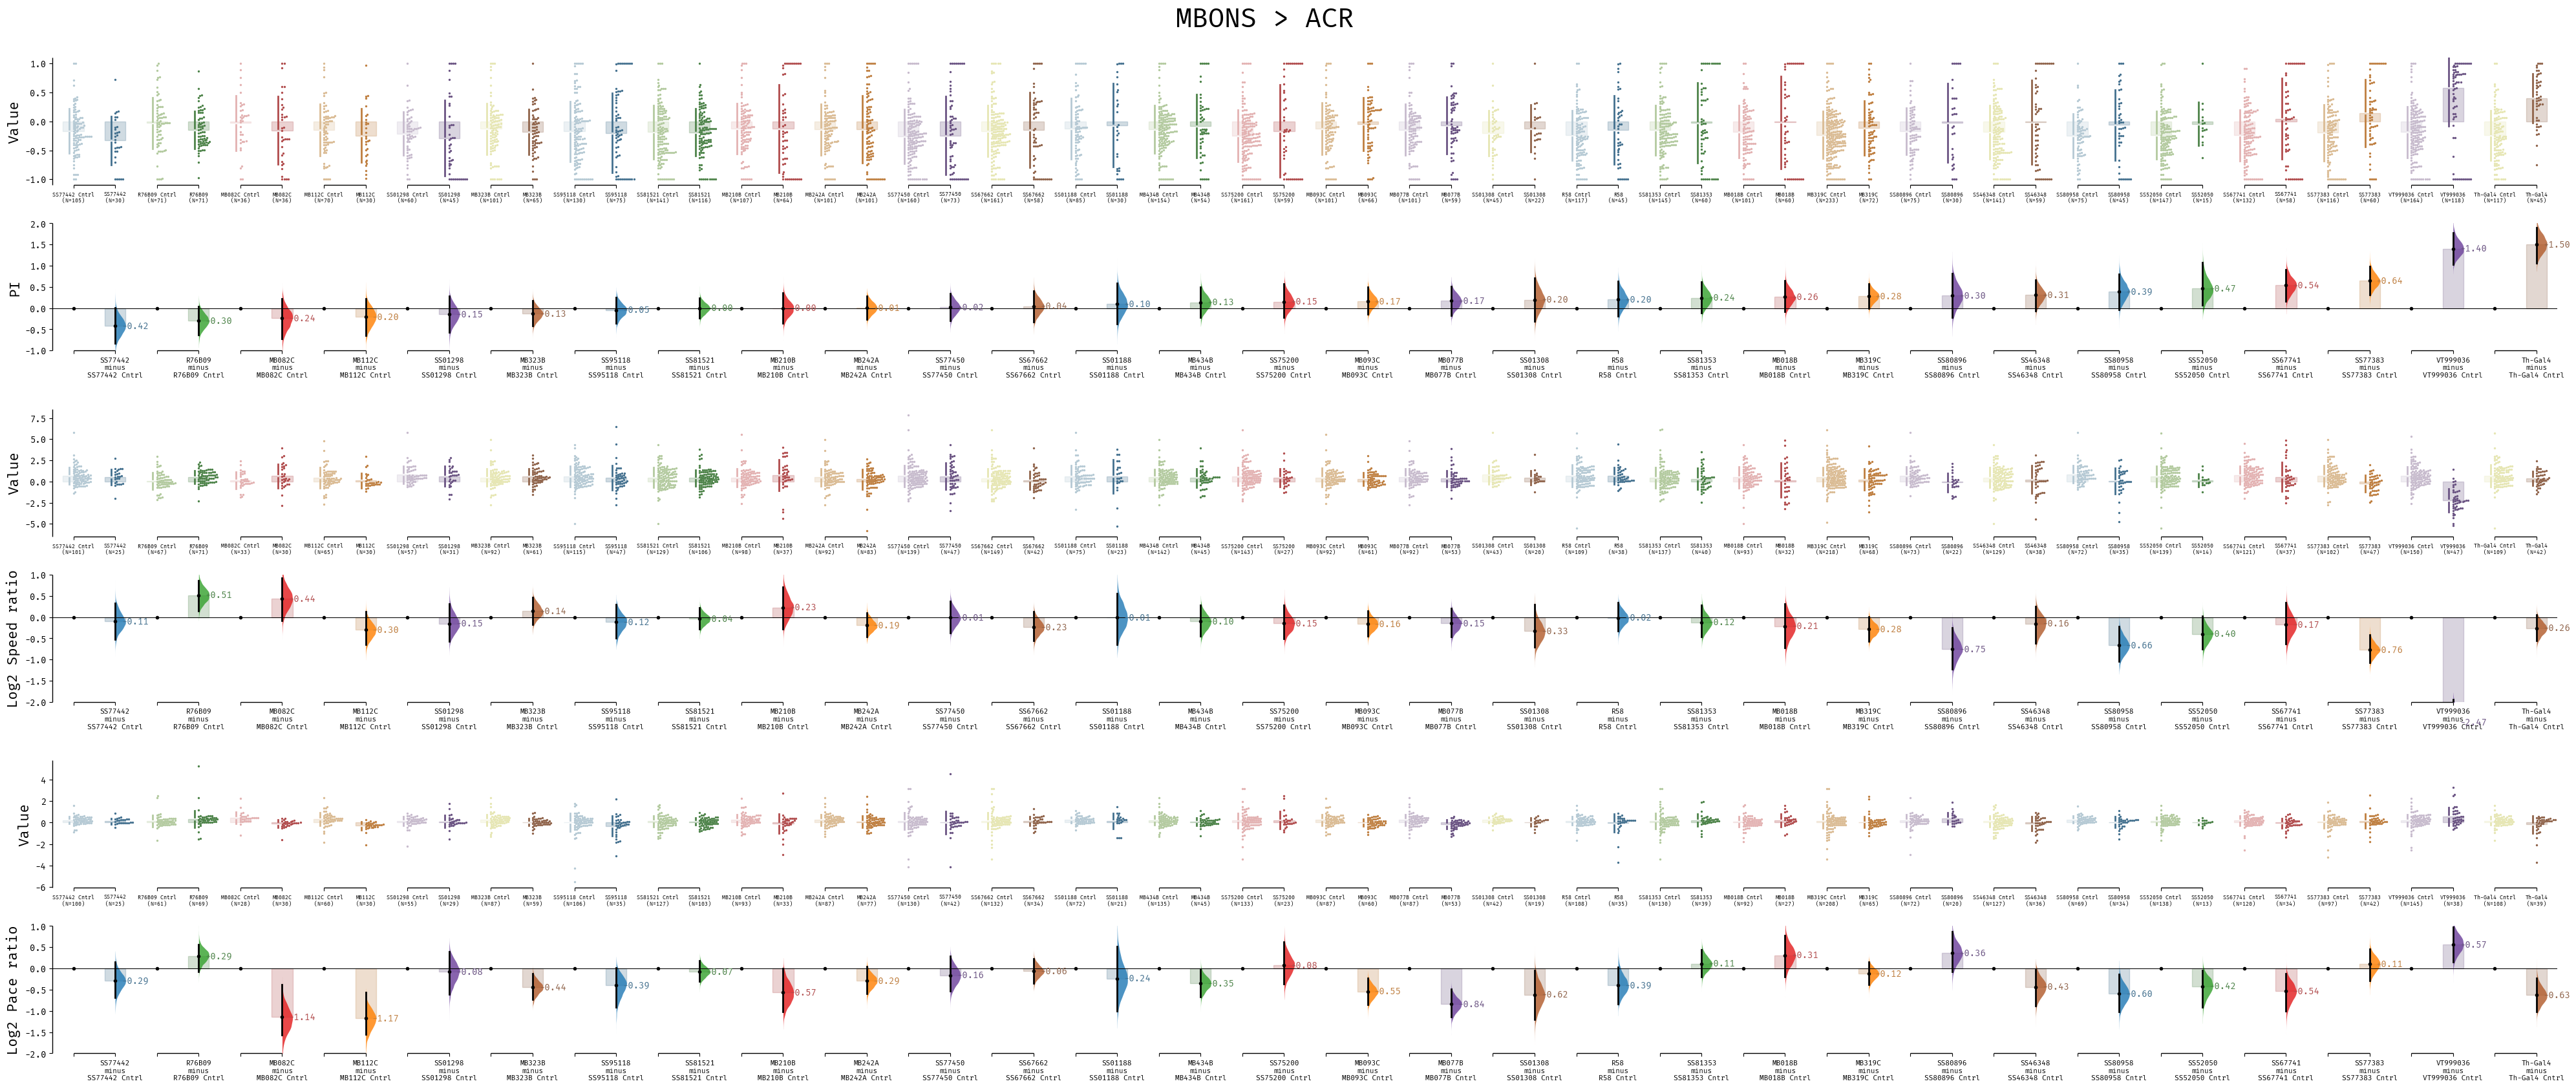

In [7]:
f, axx = plt.subplots(nrows=3, ncols=1,
                    figsize=(50
                             ,20) # ensure proper width-wise spacing.
                   )
piplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=0.5, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="PI", contrast_ylim=(-1,2), fontsize_contrastylabel= 16, fontsize_rawylabel=16, fontsize_delta2label=16, ax=axx.flat[0]);

spplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=0.5, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="Log2 Speed ratio", contrast_ylim=(-2,1), fontsize_contrastylabel= 16, fontsize_rawylabel=16,fontsize_delta2label=16,ax=axx.flat[1]);

pcplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=0.5, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="Log2 Pace ratio", contrast_ylim=(-2,1), fontsize_contrastylabel= 16, fontsize_rawylabel=16, fontsize_delta2label=16,ax=axx.flat[2]);

f.suptitle ("MBONS > " + responder, fontsize = 30, y = 0.92)

#sns.set(font_scale=0.5,  style='ticks')

In [8]:
imagefile = root + "\\images\\compiled PI Speed Pace OSAR plots at full light intensity_" + responder + '_' + date
f.savefig(imagefile + '.png', bbox_inches="tight", dpi=600)

## Heatmap of single responder


In [10]:
responder = "Chrimson2"

In [11]:
filepath = root + "20251023_" + responder + "_totalcompilation.csv"
df2= pd.read_csv(filepath, index_col=0)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [12]:
dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
dfspeed, notsortedlist, notdabestlist = chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')
dfpace, pacesortedlist, pacedabestlist = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')
dflei, leisortedlist, leidabestlist = chartplottingdabest(dfi, basegenotype, 'light_attraction_index_Pattern 01')

piplot = dabest.load(dfpi, idx=dabestlist)
spplot = dabest.load(dfspeed, idx=dabestlist)
pcplot = dabest.load(dfpace, idx=dabestlist)
leiplot = dabest.load(dflei, idx=dabestlist)

In [13]:
from functools import reduce

pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
leitable = pd.DataFrame({'MBON': leiplot.hedges_g.statistical_tests['test'],'Δ Light Attraction Index': leiplot.hedges_g.statistical_tests['difference']})
tabletotallst = [pitable, sptable, pctable, leitable]

tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

tabletotal['responder'] = responder

In [14]:
#lobe location
newfile2 = root + "2025collection"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

directorynew = os.path.dirname(os.path.dirname(root)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

# reading mBONlist
for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

In [15]:
tabletotal=tabletotal[~tabletotal['MBON'].isin(['R58', 'Th-Gal4'])]
#tabletotal

# lstofylobes = ['VT999036', 'SS75200', 'SS46348', 'SS77450', 'SS67662', 'SS81521', 'SS01308', 'SS01188', 'SS67741', 'SS77383', 'SS95118']
# dfylobes = pd.DataFrame()
# for p in lstofylobes:
#     dfylobes = pd.concat([dfylobes, tabletotal[tabletotal['MBON'] == p]], axis = 0) 
# dfylobes = dfylobes.reset_index(drop=True)

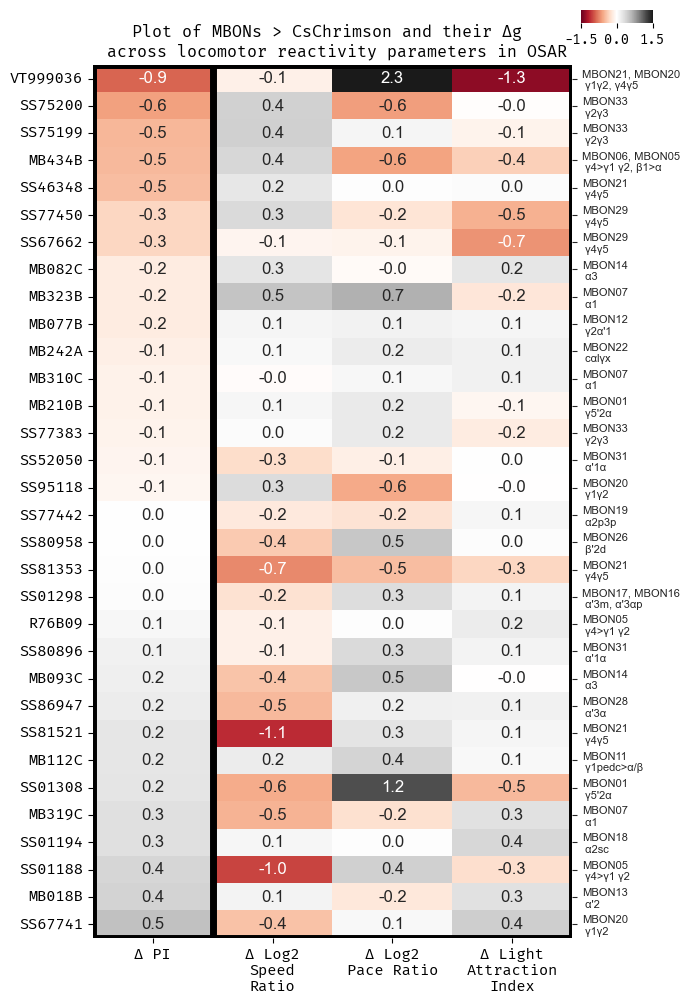

In [16]:
#mini list of only SPECIFIC responder
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

dfoneresponder = tabletotal.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="Chrimson2"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="ACR"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

plt.rcParams["font.family"] = "Fira Mono"

#specificlist
# lstofmbonsiwant = [""]
# df_specificmbon = pd.DataFrame()
# for n in lstofmbonsiwant:
#     df_specificmbon = pd.concat([df_specificmbon, dfreg_specificresponder[dfreg_specificresponder['MBON'] == n]])
    
df60 = df_specificmbon.set_index(['MBON'])
df60 = df60.drop(['responder'], axis =1)
fig1, ax4 = plt.subplots(figsize=(7, 10))     

#adding extra axes label
lobloclst = []
mbonloclst = []
for n in df_specificmbon['MBON']:
    df600 = df_specificmbon.copy()
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df600['Lobe'] = lobloclst
df600['Name'] = mbonloclst

#df600 = df600.sort_values(by = "Name", ascending=True).reset_index(drop=True)
df60extra = df600.iloc[:,:-2].set_index('MBON').drop(['responder'], axis = 1)   #change depending on parameters

newdf600 = pd.DataFrame()
naming = df600['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df600['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf600['Merge'] = newlabel

#colorbar
cax = inset_axes(ax4,
                 width="15%",  # width: 40% of parent_bbox width
                 height="1.5%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.11, 1.08, 1, 1),
                 bbox_transform=ax4.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    
       
j7 = sns.heatmap(df60extra, ax = ax4, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=True, yticklabels=True,
                 clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 12, }) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
#twilight_shifted also a possible color

j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 11)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 30, fontsize = 11)
wrap_labels(j7, 10)


# Drawing the frame for subplot 1
j7.axhline(y = 0, color = 'k', linewidth = 5) 
j7.axhline(y = len(df60extra), color = 'k', linewidth = 5) 
j7.axvline(x = 0, color = 'k', linewidth = 5) 
j7.axvline(x = 1, color = 'k', linewidth = 5) 
j7.axvline(x = len(df60extra.columns), color = 'k', linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())


#y labels for mbon lobes and naming
labellinglist = newdf600['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
    #inserts blank space after every list name
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)

j7.set_title('Plot of MBONs > ' + responderrename +' and their Δg \n across locomotor reactivity parameters in OSAR', x=0.5, weight='bold', fontsize =12)

fig1.tight_layout()

#plt.savefig(root + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)

## Forest plot of all genotypes with swarm and contrast 

In [8]:
def forestplot_multiplot(sorteddf, df1, parameter):
    lst = []
    names =[]
    for n in sorteddf['MBON']:
        tempdf1 = df1[(df1['MBON'] == n)].reset_index(drop=True)
        dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y= parameter)
        lst.append(dbfeature)
        names.append(n)
    return lst, names

In [9]:

responder = "ACR"
#from dabest.forest_plot import forest_plot
compiled = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\20250311_" + responder + "_totalcompilation.csv"
dfcompiled= pd.read_csv(compiled, index_col=0)
dfcompiled.replace([np.inf, -np.inf], np.nan, inplace=True)
dfcompiled.rename(columns={'driver': 'MBON'}, inplace = True)
dfcompiled=dfcompiled[~dfcompiled['MBON'].isin(['R58', 'Th-Gal4'])]

In [58]:
#setting fixed sorted list

#df1 = dfcompiled[(dfcompiled['light_intensity']=='Full')].loc[:,['driver','light_intensity','status','pi_smoothed_Pattern 01', 'reversal_light_pi', 'traversal_light_pi', 'light_attraction_index_Pattern 01', 'log2_pace_ratio_Pattern 01']].reset_index(drop=True)
df1 = dfcompiled[(dfcompiled['light_intensity']=='Half') | (dfcompiled['light_intensity']=='Full')].loc[:,['MBON','light_intensity','status','pi_smoothed_Pattern 01', 'log2_speed_ratio_Pattern 01','log2_pace_ratio_Pattern 01','light_attraction_index_Pattern 01']].reset_index(drop=True)

sorteddf = pd.DataFrame()

for n in df1['MBON'].unique().tolist():
    dbfeature = dabest.load(df1[(df1['MBON'] == n)].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01")
    tempdf = pd.DataFrame()
    tempdf['MBON'] = [n]
    tempdf['difference']= [float(dbfeature.hedges_g.statistical_tests.difference)]
    sorteddf = pd.concat([sorteddf, tempdf], axis =0)

sorteddf = sorteddf.sort_values(by=['difference']).reset_index(drop=True)

In [59]:
lstpi, namepi = forestplot_multiplot(sorteddf, df1, "pi_smoothed_Pattern 01")
lstsp, namesp = forestplot_multiplot(sorteddf, df1, "log2_speed_ratio_Pattern 01")
lstpc, namepc = forestplot_multiplot(sorteddf, df1, "log2_pace_ratio_Pattern 01")
lstlei, namelei = forestplot_multiplot(sorteddf, df1, "light_attraction_index_Pattern 01")

## Generates excel files

In [60]:
# to generate excel files only
parameters= ["pi_smoothed_Pattern 01", "log2_speed_ratio_Pattern 01", "log2_pace_ratio_Pattern 01", "light_attraction_index_Pattern 01"]
parameters_rename= ["Δ PI", "Δ Log2_Speed_ratio", "Δ Log2_Bout Speed_ratio", "Δ Light Attraction Index"]

result_df = pd.DataFrame({'MBON': sorteddf['MBON'].unique()})

for parameter, newname in zip(parameters, parameters_rename):
    differences = []
    
    for n in result_df['MBON']:
        tempdf1 = df1[(df1['MBON'] == n)].reset_index(drop=True)
        dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"), x="status", y=parameter)
        differences.append(dbfeature.hedges_g.statistical_tests.difference[0])
    
    # Add as new column
    result_df[newname] = differences

result_df.to_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR_" + responder + ".xlsx", index = False)

## Forest plot (contrast only)

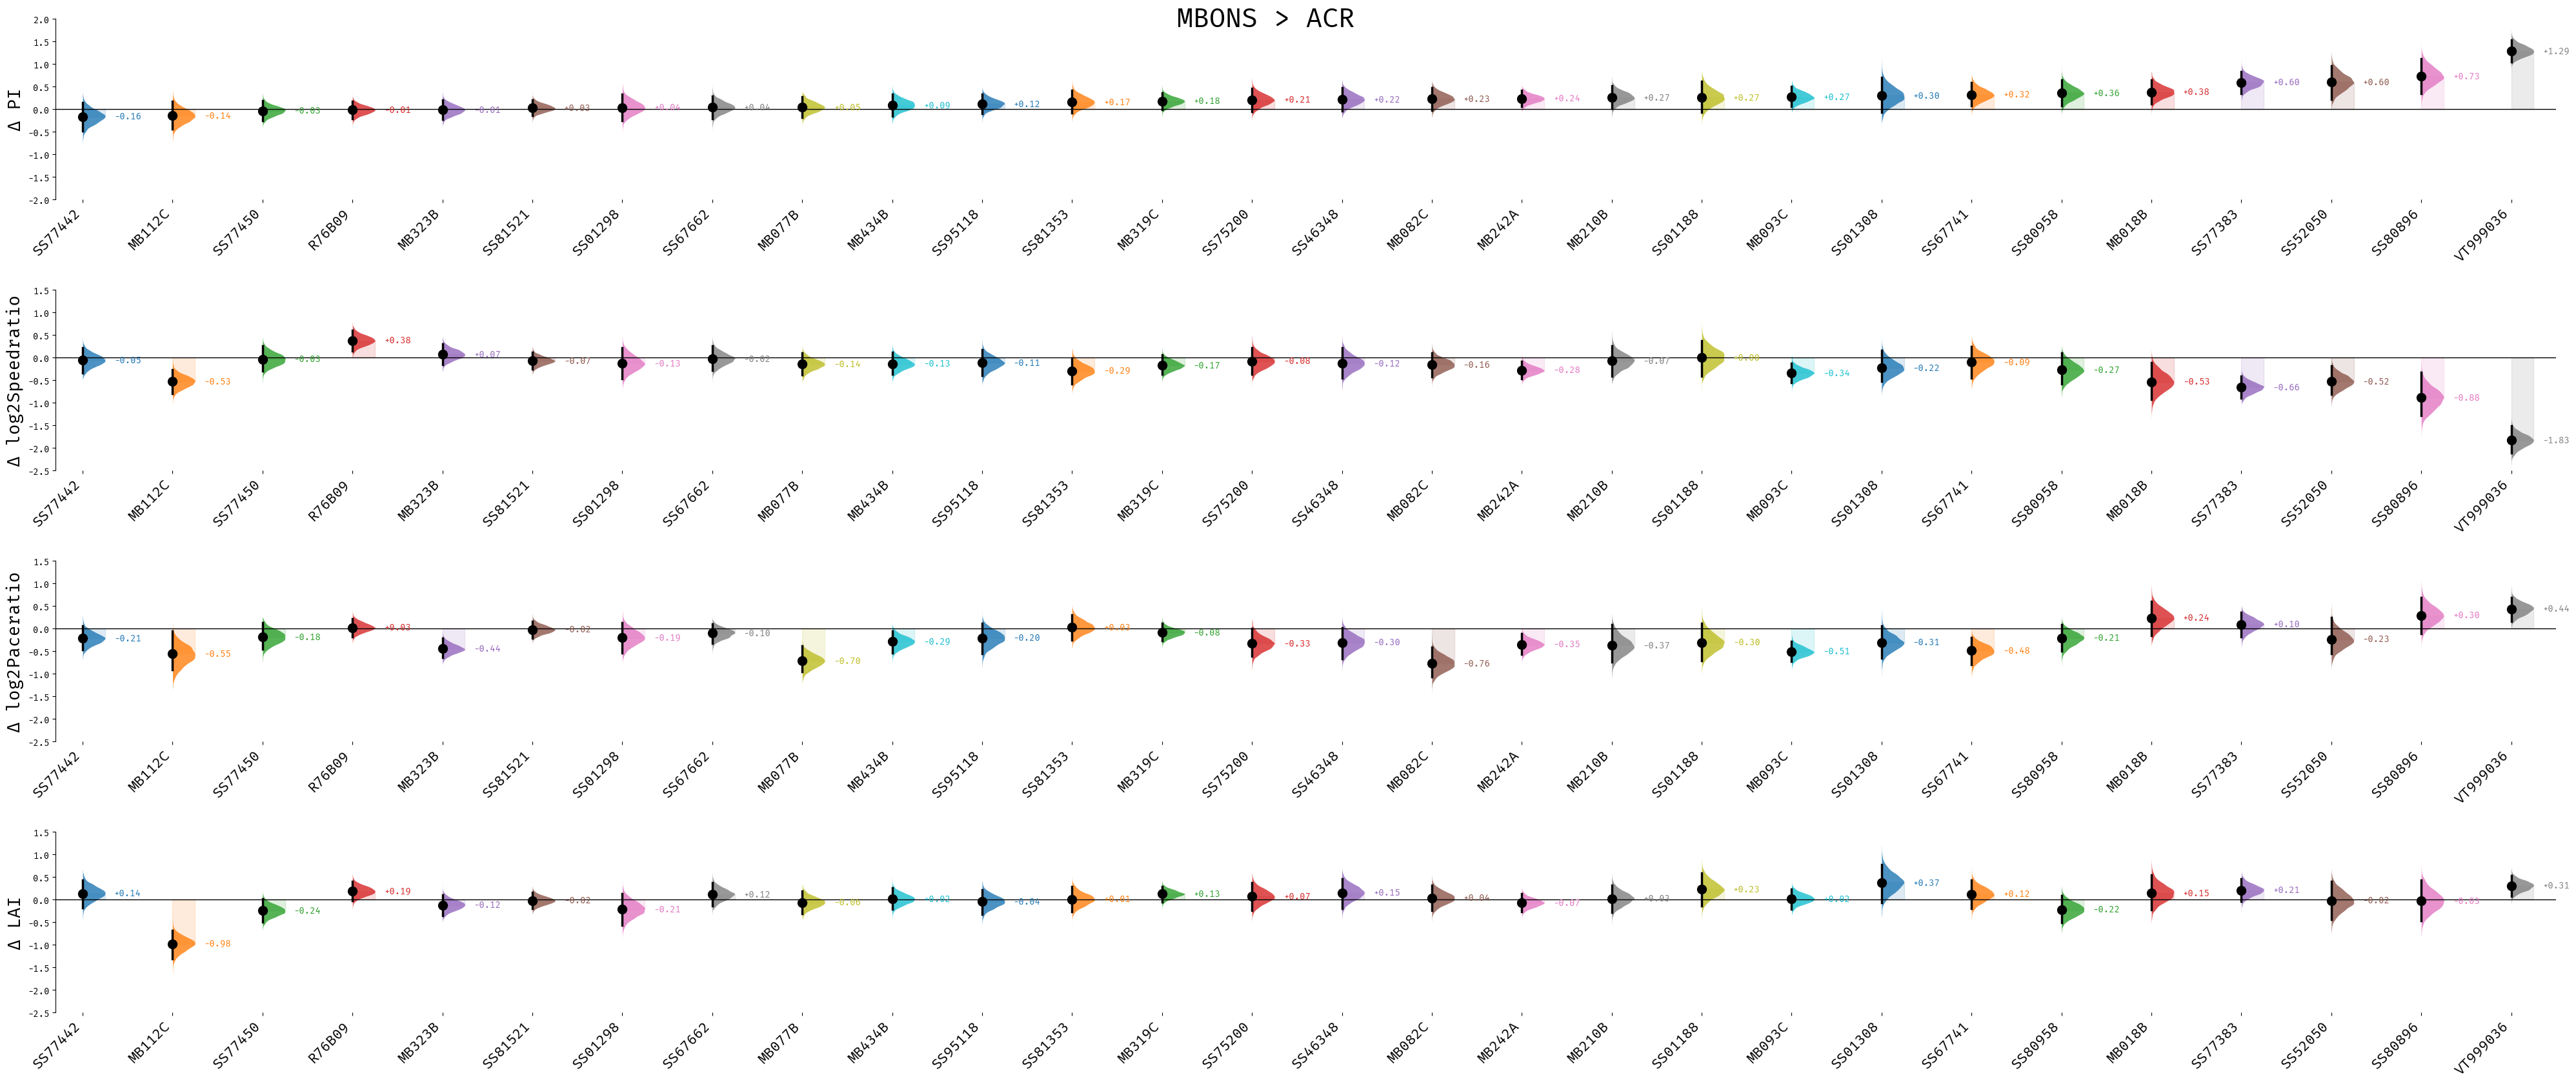

In [25]:
f2, axx2 = plt.subplots(nrows=4, ncols=1,
                    figsize=(50
                             ,20), gridspec_kw= {'hspace': 0.5} # ensure proper width-wise spacing.
                   )
dabest.forest_plot(data = lstpi, effect_size= "delta_g", labels = namepi, idx=[[0]]*len(namepi), ylabel= "Δ PI", ylabel_fontsize=20, labels_fontsize=16, ax=axx2.flat[0],  ylim = [-2, 2]);

dabest.forest_plot(data = lstsp, effect_size= "delta_g", labels = namesp, idx=[[0]]*len(namesp), ylabel= "Δ log2Speedratio", ylabel_fontsize=20, labels_fontsize=16, ax=axx2.flat[1], ylim = [-2.5, 1.5]);

dabest.forest_plot(data = lstpc, effect_size= "delta_g", labels = namepc, idx=[[0]]*len(namepc), ylabel= "Δ log2Paceratio", ylabel_fontsize=20, labels_fontsize=16, ylim = [-2.5, 1.5], ax=axx2.flat[2]);

dabest.forest_plot(data = lstlei, effect_size= "delta_g", labels = namelei, idx=[[0]]*len(namelei), ylabel= "Δ LAI", ylabel_fontsize=20, labels_fontsize=16, ylim = [-2.5, 1.5], ax=axx2.flat[3]);

f2.suptitle ("MBONS > " + responder, fontsize = 30, y = 0.89)

#sns.set(font_scale=0.5,  style='ticks')

imagefile = root + "\\images\\forest PI Speed Pace OSAR plots at half and full light intensity_" + responder + '_' + date
f2.savefig(imagefile + '.png', bbox_inches="tight", dpi=600)


## Clustering

In [5]:
def forestplot_clusterplot(sorteddf, df1):
    parameterdf = pd.DataFrame()
    parameterdf['MBON'] = sorteddf['MBON']
    parameter = ["pi_smoothed_Pattern 01", "log2_speed_ratio_Pattern 01", "log2_pace_ratio_Pattern 01", "light_attraction_index_Pattern 01"]
    for k in parameter:
        perparameter = []
        for n in zip(sorteddf['MBON']):
            tempdf1 = df1[(df1['MBON'] == n)].reset_index(drop=True)
            dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y= k)
            dgvalue= float(dbfeature.hedges_g.statistical_tests.difference)
            perparameter.append(dgvalue)
        parameterdf[k] = perparameter
            
    return parameterdf

In [25]:
responder = "ACR"
#from dabest.forest_plot import forest_plot
compiled = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\20250311_" + responder + "_totalcompilation.csv"
dfcompiled= pd.read_csv(compiled, index_col=0)
dfcompiled.replace([np.inf, -np.inf], np.nan, inplace=True)
dfcompiled.rename(columns={'driver': 'MBON'}, inplace = True)
dfcompiled=dfcompiled[~dfcompiled['MBON'].isin(['R58', 'Th-Gal4'])]

In [26]:
#setting fixed sorted list

df1 = dfcompiled[(dfcompiled['light_intensity']=='Full')].loc[:,['MBON','light_intensity','status','pi_smoothed_Pattern 01', 'log2_speed_ratio_Pattern 01','log2_pace_ratio_Pattern 01','light_attraction_index_Pattern 01']].reset_index(drop=True)
#df1 = dfcompiled[(dfcompiled['light_intensity']=='Half') | (dfcompiled['light_intensity']=='Full')].loc[:,['MBON','light_intensity','status','pi_smoothed_Pattern 01', 'log2_speed_ratio_Pattern 01','log2_pace_ratio_Pattern 01','light_attraction_index_Pattern 01']].reset_index(drop=True)

sorteddf = pd.DataFrame()

for n in df1['MBON'].unique().tolist():
    dbfeature = dabest.load(df1[(df1['MBON'] == n)].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01")
    tempdf = pd.DataFrame()
    tempdf['MBON'] = [n]
    tempdf['difference']= [float(dbfeature.hedges_g.statistical_tests.difference)]
    sorteddf = pd.concat([sorteddf, tempdf], axis =0)

sorteddf = sorteddf.sort_values(by=['difference']).reset_index(drop=True)

In [27]:
parameterdf = pd.DataFrame()
parameterdf['MBON'] = sorteddf['MBON']
parameter = ["pi_smoothed_Pattern 01", "log2_speed_ratio_Pattern 01", "log2_pace_ratio_Pattern 01", "light_attraction_index_Pattern 01"]
parameterrename = ["Δg PI", "Δg Log SR", "Δg Pace Ratio", "Δg LAI"]
for k, p in zip(parameter, parameterrename):
    perparameter = []
    for n in sorteddf['MBON']:
        tempdf1 = df1[(df1['MBON'] == n)].reset_index(drop=True)
        dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y= k)
        dgvalue= float(dbfeature.hedges_g.statistical_tests.difference)
        perparameter.append(dgvalue)
    parameterdf[p] = perparameter


In [28]:
lobloclst = []
mbonloclst = []
for n in parameterdf['MBON']:
    df600 = parameterdf.copy()
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df600['Lobe'] = lobloclst
df600['Name'] = mbonloclst

weighted euclidean


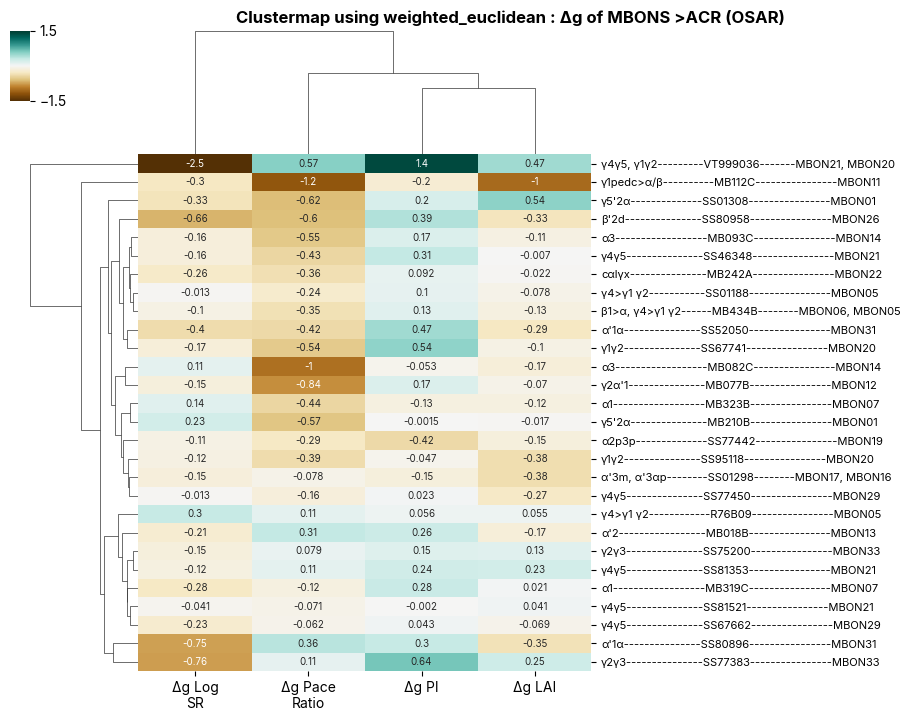

In [29]:
methodlist = ['weighted']
metriclist = ['euclidean']

if responder == 'Chrimson2':
    colormap = 'RdGy'
    
if responder == 'ACR':
    colormap = 'BrBG'
    
df601 = df600.copy()
df601['totalnaming'] = df601['MBON'] + "; " + df601['Name'] + "; " + df601['Lobe']

df601newset = df601.set_index('totalnaming').drop(['Lobe', 'Name', 'MBON'], axis =1)

ylabellist = []
for n, k, z in zip(df601['MBON'],df601['Lobe'], df601['Name']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)

plt.rcParams["font.family"] = "Inter"

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df601newset, cmap=colormap, metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5, annot=True, annot_kws={"size": 7},
                            cbar_kws = dict(shrink = 0.15, ticks = [-1.5,1.5]), figsize=(10, 7), cbar_pos=(0, 0.87, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_yticklabels(ax.get_yticklabels(), rotation = 0, fontsize = 8)
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : Δg of MBONS >' + responder + " (OSAR)", weight='bold', fontsize =12, y =1.0)

        
        plt.savefig(root + "images\\" + date + "_" + responder + "(OSAR)_clustermap_" + methodd + "_" + metricc + ".png", dpi = 1200)
        plt.savefig(root + "images\\" + date + "_" + responder + "(OSAR)_clustermap_" + methodd + "_" + metricc + ".png", dpi = 1200)

## Forest plot of specific MBONs

In [10]:
def forestplot_singleplot(mbonname, df1, parameter):
    lst = []
    for n in parameter:
        tempdf1 = df1[(df1['MBON'] == mbonname)].reset_index(drop=True)
        dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y= n)
        lst.append(dbfeature)
    return lst

In [11]:
#from dabest.forest_plot import forest_plot
responder = "Chrimson2"
compiled = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\20250514_" + responder + "_totalcompilation.csv"
dfcompiled= pd.read_csv(compiled, index_col=0)
dfcompiled.replace([np.inf, -np.inf], np.nan, inplace=True)
dfcompiled.rename(columns={'driver': 'MBON'}, inplace = True)
dfcompiled=dfcompiled[~dfcompiled['MBON'].isin(['R58', 'Th-Gal4'])]

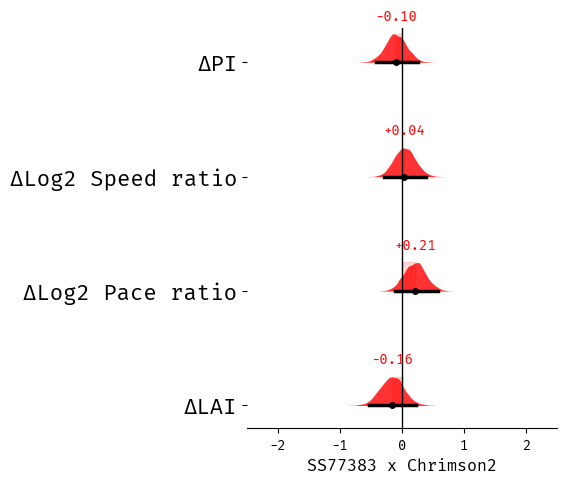

In [20]:
driver_forest = "SS77383"

if "Chrimson2" in responder:
      color  = "#FF0000"
else:
      color = "#2e6f40"
      
df1 = dfcompiled[(dfcompiled['light_intensity']=='Full')].loc[:,['MBON','light_intensity','status','pi_smoothed_Pattern 01', 'log2_speed_ratio_Pattern 01','log2_pace_ratio_Pattern 01','light_attraction_index_Pattern 01']].reset_index(drop=True)
osarmetriclst = ["pi_smoothed_Pattern 01", "log2_speed_ratio_Pattern 01", "log2_pace_ratio_Pattern 01", "light_attraction_index_Pattern 01"]
osarlabellst= ['ΔPI' , 'ΔLog2 Speed ratio' , 'ΔLog2 Pace ratio', 'ΔLAI']
s1df = forestplot_singleplot(driver_forest, df1, osarmetriclst)

singleplotfig = dabest.forest_plot(data = s1df, effect_size= "delta_g", labels = osarlabellst, idx=[[0]]*len(osarlabellst), labels_fontsize=16, marker_size=4, custom_palette=[color]*4,
                   horizontal = True, ylim = [-2.5, 2.5], ylabel= driver_forest + " x " + responder );

In [21]:
imagefile = root + "\\images\\" + driver_forest + " x " + responder + "_forest PI Speed Pace OSAR plots at full light intensity_" + date
singleplotfig.savefig(imagefile + '.svg', bbox_inches="tight", dpi=600)

## Single genotype plot


In [13]:
filepath = root + "20250310_" + responder + "_totalcompilation.csv"
df2= pd.read_csv(filepath, index_col=0)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

basegenotype

array(['MB018B', 'MB077B', 'MB082C', 'MB093C', 'MB112C', 'MB210B',
       'MB242A', 'MB310C', 'MB319C', 'MB323B', 'MB434B', 'R58', 'R76B09',
       'SS01188', 'SS01194', 'SS01298', 'SS01308', 'SS46348', 'SS52050',
       'SS67662', 'SS67741', 'SS75199', 'SS75200', 'SS77383', 'SS77442',
       'SS77450', 'SS80896', 'SS80958', 'SS81353', 'SS81521', 'SS95118',
       'Th-Gal4', 'VT999036'], dtype=object)

In [14]:
basegenotype = ["SS75200"]

In [15]:
def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr = pd.concat([filter2[parameter].reset_index(drop=True).rename(names + " Cntrl"),
                      filter1[parameter].reset_index(drop=True).rename(names)], axis=1)
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst)    
    
    return test

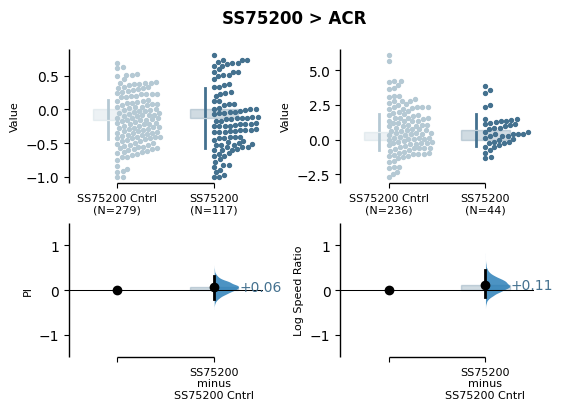

In [16]:
for n in basegenotype:
   
   figure2, axx = plt.subplots(nrows=1, ncols=2,
                    figsize=(6
                             ,4), gridspec_kw={'wspace': 0.4}
                                # ensure proper width-wise spacing.
                   )

   singleplottingdabest(dfi, n, "pi_smoothed_Pattern 01_baseline_corrected").hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                         custom_palette="Paired", contrast_label="PI", contrast_ylim=(-1.5,1.5), ax=axx.flat[0]);

   singleplottingdabest(dfi, n, "log2_speed_ratio_Pattern 01").hedges_g.plot(float_contrast=False, fontsize_rawylabel=8,fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                        custom_palette="Paired", contrast_label="Log Speed Ratio", contrast_ylim=(-1.5,1.5), ax=axx.flat[1]);

   figure2.tight_layout()
   figure2.suptitle( n + " > " + responder, fontweight='bold', size = 12, y=0.98)

   #filesaving
   # filename = folderpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2024images\\" +  n + " x " + genot + '_OSAR_Full_light'
   # figure2.savefig(filename + '.svg', bbox_inches="tight", dpi=600)



## 4 koma OSAR plot

In [9]:
dir1 = root + "2025collection\\"
driver = "SS80974"
responder = "ACR"
transgenic = driver + " x " + responder
files2 = dir1 + transgenic + ".csv"
osarAnalysis =pd.read_csv(files2, index_col=0)


In [10]:
def twolightdabest(di, names, parameter, light):
    
    if light == 'Half' or light == 'Full':
        dfi = di[(di['light_intensity']==light)].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['status'] == 'Offspring')].reset_index(drop=True)
        filter2 = dfi[(dfi['status'] == 'Sibling')].reset_index(drop=True)
        lightnaming = "LIGHT ON"     #naming in the plot itself would show up as LIGHT ON or LIGHT OFF
        dfrr = pd.concat([filter2[parameter].reset_index(drop=True).rename("Control_" + lightnaming),
                          filter1[parameter].reset_index(drop=True).rename("Test_" + lightnaming)], axis=1)
       
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
        return test

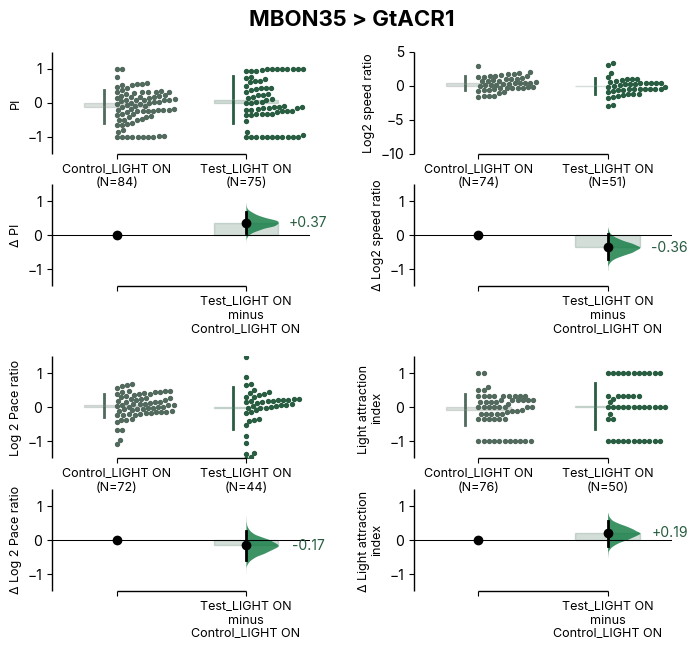

In [11]:
#Full

dfi=osarAnalysis[(osarAnalysis['light_intensity']=='Full')].reset_index(drop=True)
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)
basegenotype = dfi['MBON'].unique()

figosarfig, axosar = plt.subplots(2,2, figsize = (8,7), gridspec_kw={'wspace':0.4, 'hspace':0.3})
mbonnumber = str(lobelocation[lobelocation['MBON'] == driver]['MBON number'].values[0])
if responder == "Chrimson2":
    sibling_half_color = "#d77c24"
    half_colors = "#daab7d"
    sibling_full_color = "#c29999"
    full_colors = "#cf0c16"
    responderrename = "CsChrimson"
    transgenicnaming = transgenic.replace("Chrimson2", "CsChrimson")
    
    
if responder == "ACR":
    sibling_half_color = "#759c8c"
    half_colors = "#0fab6d"
    sibling_full_color = "#46755c"
    full_colors = "#0d783f"
    responderrename = "GtACR1"
    transgenicnaming = transgenic.replace("ACR", "GtACR1")

  
my_color_palette = {"Control_LIGHT ON" : sibling_full_color,
                        "Test_LIGHT ON"    : full_colors, 
                      }

twolightdabest(dfi, basegenotype,'pi_smoothed_Pattern 01', 'Full').hedges_g.plot(float_contrast=False, fontsize_rawylabel=9, fontsize_rawxlabel=9, raw_ylim=(-1.5,1.5), 
                                                                      fontsize_contrastxlabel=9, fontsize_contrastylabel=9, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette,raw_label="PI", contrast_label="Δ PI", contrast_ylim=(-1.5,1.5), ax = axosar.flat[0]);

twolightdabest(dfi, basegenotype,'log2_speed_ratio_Pattern 01', 'Full').hedges_g.plot(float_contrast=False, fontsize_rawylabel=9, fontsize_rawxlabel=9, raw_ylim=(-10,5),
                                                                      fontsize_contrastxlabel=9, fontsize_contrastylabel=9, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette, raw_label="Log2 speed ratio",contrast_label="Δ Log2 speed ratio", contrast_ylim=(-1.5,1.5), ax = axosar.flat[1]);

twolightdabest(dfi, basegenotype,'log2_pace_ratio_Pattern 01', 'Full').hedges_g.plot(float_contrast=False, fontsize_rawylabel=9, fontsize_rawxlabel=9, raw_ylim=(-1.5,1.5),
                                                                      fontsize_contrastxlabel=9, fontsize_contrastylabel=9, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette= my_color_palette, raw_label="Log 2 Pace ratio",contrast_label="Δ Log 2 Pace ratio", contrast_ylim=(-1.5,1.5), ax = axosar.flat[2]);

twolightdabest(dfi, basegenotype,'light_attraction_index_Pattern 01', 'Full').hedges_g.plot(float_contrast=False, fontsize_rawylabel=9, fontsize_rawxlabel=9, raw_ylim=(-1.5,1.5),
                                                                      fontsize_contrastxlabel=9, fontsize_contrastylabel=9, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette, raw_label="Light attraction \nindex",contrast_label="Δ Light attraction \nindex", contrast_ylim=(-1.5,1.5), ax = axosar.flat[3])


figosarfig.suptitle(mbonnumber + " > " + responderrename, weight = "bold", fontsize = 16, y=0.94)
matplotlib.rcParams['svg.fonttype'] = 'none'
plt.savefig(filesavedir + date + transgenicnaming + "_4komaosarplots.svg")


## half and full

AttributeError: 'NoneType' object has no attribute 'hedges_g'

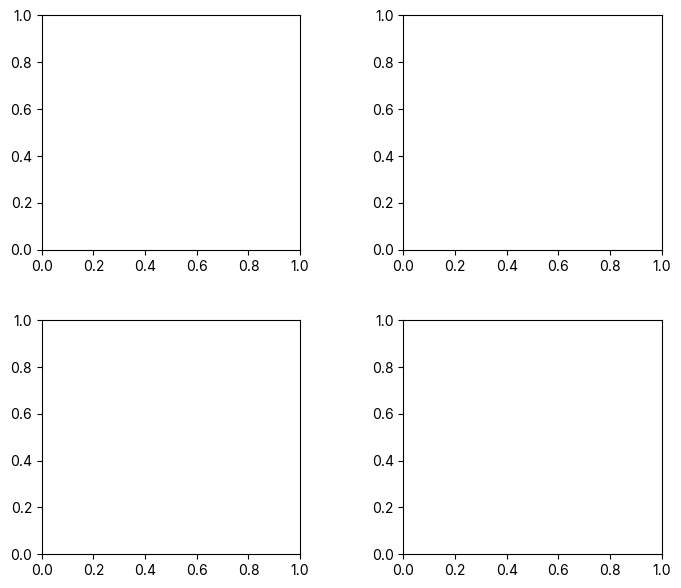

In [13]:
# Half and Full

#dfi=osarAnalysis[(osarAnalysis['light_intensity']=='Half') | (osarAnalysis['light_intensity']=='Full')].reset_index(drop=True)
dfi=osarAnalysis[(osarAnalysis['light_intensity']=='Full')].reset_index(drop=True)
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)
basegenotype = dfi['MBON'].unique()

figosarfig, axosar = plt.subplots(2,2, figsize = (8,7), gridspec_kw={'wspace':0.4, 'hspace':0.3})

if responder == "Chrimson2":
    sibling_half_color = "#d77c24"
    half_colors = "#daab7d"
    sibling_full_color = "#c29999"
    full_colors = "#cf0c16"
    
    
if responder == "ACR":
    sibling_half_color = "#759c8c"
    half_colors = "#0fab6d"
    sibling_full_color = "#46755c"
    full_colors = "#0d783f"

  
my_color_palette = {"Cntrl_Half" : sibling_half_color,
                        "Half"    : half_colors,
                      "Cntrl_Full" : sibling_full_color,
                        "Full"    : full_colors, 
                      }

twolightdabest(dfi, basegenotype,'pi_smoothed_Pattern 01', 'Both').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, raw_ylim=(-1.5,1.5), 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette, contrast_label="PI", contrast_ylim=(-1.5,1.5), ax = axosar.flat[0]);

twolightdabest(dfi, basegenotype,'log2_speed_ratio_Pattern 01', 'Both').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, raw_ylim=(-10,5),
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette, contrast_label="Log2 speed ratio", contrast_ylim=(-1.5,1.5), ax = axosar.flat[1]);

twolightdabest(dfi, basegenotype,'log2_pace_ratio_Pattern 01', 'Both').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, raw_ylim=(-1.5,1.5),
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette= my_color_palette, contrast_label="Log 2 Pace ratio", contrast_ylim=(-1.5,1.5), ax = axosar.flat[2]);

twolightdabest(dfi, basegenotype,'light_attraction_index_Pattern 01', 'Both').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, raw_ylim=(-1.5,1.5),
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette=my_color_palette, contrast_label="Light attraction index", contrast_ylim=(-1.5,1.5), ax = axosar.flat[3])


figosarfig.suptitle(transgenic, weight = "bold", fontsize = 14, y=0.94)
